In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [28]:
df = pd.read_csv('./data/dataset-no-recessions.csv', parse_dates=['Date']).set_index('Date').sort_index()
df.head(3)

,BAA10Y,DFF,DGS10,DGS2,CPIAUCSL,CPIAUCSL_days_since,PPIACO,PPIACO_days_since,PCEPI,PCEPI_days_since,...,SP500,NFCI,NFCI_days_since,DAAA,DBAA,UMCSENT,UMCSENT_days_since,TCU,TCU_days_since,DCOILWTICO
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-05,1.89,8.2,7.99,7.9,127.5,4,114.9,4,58.553,4,...,352.200012,0.034,0,8.88,9.88,93.0,4,82.4179,4,23.07
1990-01-06,1.89,8.2,7.99,7.9,127.5,5,114.9,5,58.553,5,...,352.200012,0.034,1,8.88,9.88,93.0,5,82.4179,5,23.07
1990-01-07,1.89,8.2,7.99,7.9,127.5,6,114.9,6,58.553,6,...,352.200012,0.034,2,8.88,9.88,93.0,6,82.4179,6,23.07


In [29]:
# Forecast horizon (days ahead). Change this to forecast further out.
H = 1

# Supervised setup: features at time t predict BAA10Y at time t+H.
# Shifting by -H aligns each row's target with the future value.
y_future = df['BAA10Y'].shift(-H)
y_now    = df['BAA10Y']
X_full   = df.drop(columns=['BAA10Y'])

# Drop rows where either the current spread (needed for naive baseline)
# or the future spread (the target) is NaN.
mask = y_future.notna() & y_now.notna()
X = X_full.loc[mask]
y = y_future.loc[mask]
y_t = y_now.loc[mask]  # current spread, kept for the naive last-value baseline

print(f"Horizon H = {H} day(s)")
print(f"Samples: {len(y)}  ({y.index.min().date()} → {y.index.max().date()})")

Horizon H = 1 day(s)
Samples: 11683  (1990-01-05 → 2025-12-31)


In [30]:
# Chronological split — NEVER shuffle time-series data.
# OOB error from the forest plays the role of validation (each sample is
# scored by the trees that didn't see it), so we only need a held-out test
# set. This frees up ~15% more data for training.
n = len(y)
train_end = int(n * 0.8)

X_train, X_test = X.iloc[:train_end], X.iloc[train_end:]
y_train, y_test = y.iloc[:train_end], y.iloc[train_end:]
y_t_test        = y_t.iloc[train_end:]   # current spread, kept for naive-baseline comparison

print(f"train: {y_train.index.min().date()} → {y_train.index.max().date()}  ({len(y_train)} rows)")
print(f"test:  {y_test.index.min().date()} → {y_test.index.max().date()}  ({len(y_test)} rows)")

train: 1990-01-05 → 2019-02-07  (9346 rows)
test:  2019-02-08 → 2025-12-31  (2337 rows)


In [31]:
# Sweep n_estimators from 100 to 1500 and track OOB error + tree depth.
#
# warm_start=True grows the forest incrementally — each iteration only fits
# the *new* trees rather than refitting from scratch, so the whole sweep
# costs about the same as a single 1500-tree fit.
#
# Note on time-series: OOB uses random bootstrap samples, so OOB error is
# NOT a forecast metric. Use it to choose n_estimators (where the curve
# plateaus), then evaluate the chosen model on y_val / y_test.

n_grid = list(range(100, 1501, 100))

rf = RandomForestRegressor(
    n_estimators=n_grid[0],
    oob_score=True,
    bootstrap=True,
    warm_start=True,
    n_jobs=-1,
    random_state=42,
)

oob_rmse  = []
mean_depth = []
max_depth  = []
min_depth  = []

for n in n_grid:
    rf.set_params(n_estimators=n)
    rf.fit(X_train, y_train)
    rmse = np.sqrt(mean_squared_error(y_train, rf.oob_prediction_))
    depths = np.array([t.get_depth() for t in rf.estimators_])
    oob_rmse.append(rmse)
    mean_depth.append(depths.mean())
    max_depth.append(depths.max())
    min_depth.append(depths.min())
    print(f"n_estimators={n:4d}  OOB RMSE={rmse:.4f}  "
          f"depth mean={depths.mean():5.1f}  min={depths.min():3d}  max={depths.max():3d}")

n_estimators= 100  OOB RMSE=0.0240  depth mean= 28.2  min= 25  max= 34
n_estimators= 200  OOB RMSE=0.0238  depth mean= 28.2  min= 24  max= 34
n_estimators= 300  OOB RMSE=0.0237  depth mean= 28.2  min= 24  max= 35
n_estimators= 400  OOB RMSE=0.0237  depth mean= 28.2  min= 24  max= 35
n_estimators= 500  OOB RMSE=0.0237  depth mean= 28.2  min= 24  max= 35
n_estimators= 600  OOB RMSE=0.0236  depth mean= 28.2  min= 24  max= 35
n_estimators= 700  OOB RMSE=0.0236  depth mean= 28.2  min= 24  max= 35
n_estimators= 800  OOB RMSE=0.0235  depth mean= 28.2  min= 24  max= 35
n_estimators= 900  OOB RMSE=0.0236  depth mean= 28.2  min= 24  max= 35
n_estimators=1000  OOB RMSE=0.0236  depth mean= 28.2  min= 24  max= 35
n_estimators=1100  OOB RMSE=0.0236  depth mean= 28.3  min= 24  max= 35
n_estimators=1200  OOB RMSE=0.0236  depth mean= 28.3  min= 24  max= 35
n_estimators=1300  OOB RMSE=0.0236  depth mean= 28.3  min= 24  max= 36
n_estimators=1400  OOB RMSE=0.0236  depth mean= 28.3  min= 24  max= 36
n_esti

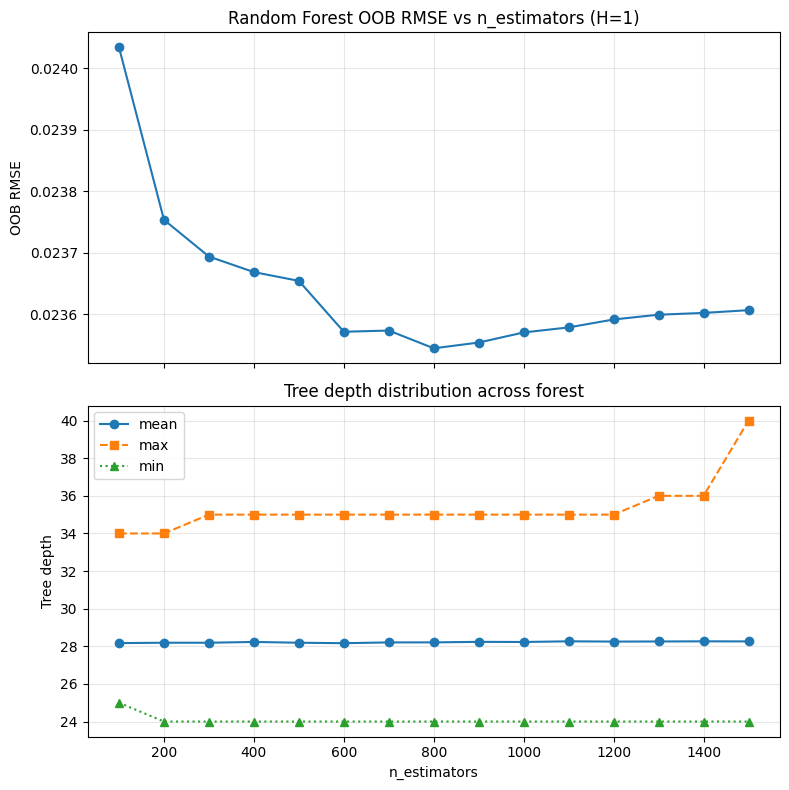

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(n_grid, oob_rmse, marker='o')
axes[0].set_ylabel('OOB RMSE')
axes[0].set_title(f'Random Forest OOB RMSE vs n_estimators (H={H})')
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_grid, mean_depth, marker='o', label='mean')
axes[1].plot(n_grid, max_depth,  marker='s', label='max', linestyle='--')
axes[1].plot(n_grid, min_depth,  marker='^', label='min', linestyle=':')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Tree depth')
axes[1].set_title('Tree depth distribution across forest')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()